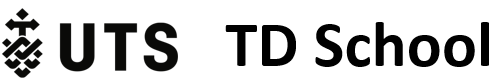

# Special Subject: Developing a Time Series Forecasting Model for Renewable Energy Generation

Santiago Montoya Mora – ID. 24898381

## Library

In [14]:
import requests
import zipfile
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.metrics import mean_squared_error

## Dataset

The data were obtained from the National Renewable Energy Laboratory (NREL) database. The values presented by this database are simulated estimates rather than direct measurements of a physical solar plant, which they calculate using historical meteorological data to predict how a commercial-scale PV system would behave under realistic conditions, allowing for an analysis of the power generation alone. The data used are specifically from Florida at coordinates: 25.15_-80.95.

LINK: [NREL Solar Data](https://www.nrel.gov/grid/solar-power-data.html "NREL Solar Data")

They have 3 tables of interest:

| Table Name             | Description                                                                                                                                                      |
|------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Actual Table**       | Contains the ‘actual’ (simulated) generation data of the PV plant, based on historical weather conditions. These values reflect the estimated production, calculated from data measured every 5 minutes. |
| **DA (Day-Ahead) Table** | Includes forecasts made with a one-day horizon (day-ahead), which predict solar generation for each hour of the next day.                                            |
| **HA4 (4-Hour Ahead) Table** | Contains the short-term forecasts, made with a 4-hour horizon.                                                                                              |


Because the table contains the power data every 5 minutes, it was transformed to have its data in hourly form, as the DA and HA4 tables are hourly. In addition to the weather data that we will use later, steps:

to convert the 5-minute readings to hourly energy, we follow these steps:

- There are 12 readings per hour since \(60 \div 5 = 12\).
- Each reading is in megawatts (MW), representing the instantaneous power at that moment.
- To obtain energy (in megawatt-hours, MWh), we multiply the power by the time interval in hours. Since each reading covers 5 minutes, the time interval is \(\frac{5}{60}\) hours.
- Therefore, the formula to calculate the hourly energy is:

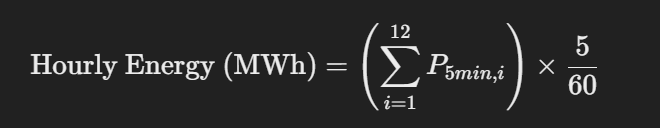


This process aggregates the 5-minute data into a single hourly measurement of energy.


In [15]:

actual_file = '../data/raw/Actual_25.15_-80.95_2006_UPV_227MW_5_Min.csv'
da_file = '../data/raw/DA_25.15_-80.95_2006_UPV_227MW_60_Min.csv'
ha4_file = '../data/raw/HA4_25.15_-80.95_2006_UPV_227MW_60_Min.csv'

df_actual = pd.read_csv(actual_file)
df_da = pd.read_csv(da_file)
df_ha4 = pd.read_csv(ha4_file)

df_ha4_renamed = df_ha4.rename(columns={'Power(MW)': 'Power(MW)_HA4'})

df_actual['LocalTime'] = pd.to_datetime(df_actual['LocalTime'], format='%m/%d/%y %H:%M', errors='coerce')
df_da['LocalTime'] = pd.to_datetime(df_da['LocalTime'], format='%m/%d/%y %H:%M', errors='coerce')
df_ha4_renamed['LocalTime'] = pd.to_datetime(df_ha4_renamed['LocalTime'], format='%m/%d/%y %H:%M', errors='coerce')

df_actual.set_index('LocalTime', inplace=True)

# Resample Actual data (5-min intervals) to hourly data:
# Sum the 12 readings within each hour and convert to energy (MWh) by multiplying by (5/60)
df_actual_energy = df_actual.resample('H').sum() * (5/60)
df_actual_energy = df_actual_energy.reset_index()

df_merged = pd.merge(df_actual_energy, df_da, on='LocalTime', how='outer', suffixes=('_ActualEnergy', '_DA'))
df_merged = pd.merge(df_merged, df_ha4_renamed, on='LocalTime', how='outer')


df_merged.head()


/tmp/ipykernel_1845/3788446268.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_actual_energy = df_actual.resample('H').sum() * (5/60)


,LocalTime,Power(MW)_ActualEnergy,Power(MW)_DA,Power(MW)_HA4
0,2006-01-01 00:00:00,0.0,0.0,0.0
1,2006-01-01 01:00:00,0.0,0.0,0.0
2,2006-01-01 02:00:00,0.0,0.0,0.0
3,2006-01-01 03:00:00,0.0,0.0,0.0
4,2006-01-01 04:00:00,0.0,0.0,0.0


In [16]:
df_da.head()

,LocalTime,Power(MW)
0,2006-01-01 00:00:00,0.0
1,2006-01-01 01:00:00,0.0
2,2006-01-01 02:00:00,0.0
3,2006-01-01 03:00:00,0.0
4,2006-01-01 04:00:00,0.0


### NASA API

To complete our data and have a more robust model we will use external weather data extracted hourly from the NASA API, this data is specific to the coordinates given by the PV plant used on the same date.

| Parameter              | Description                                                                                                    | Units       |
|------------------------|----------------------------------------------------------------------------------------------------------------|------------|
| **T2M**                | Temperature of the air measured at 2 meters above the surface.                                                 | °C          |
| **WS10M**              | Wind speed measured at 10 meters above the surface.                                                            | m/s         |
| **RH2M**               | Relative humidity at 2 meters above the surface.                                                               | %           |
| **ALLSKY_SFC_SW_DWN**  | Downward shortwave irradiance at the surface under actual sky conditions (including clouds).                   | W/m²        |
| **CLRSKY_SFC_SW_DWN**  | Downward shortwave irradiance at the surface under clear-sky conditions (no clouds).                           | W/m²        |
| **PRECTOTCORR**        | Corrected total precipitation over the time period.                                                            | mm          |
| **ALLSKY_KT**          | Clear-sky index: ratio of observed irradiance to the irradiance under clear-sky conditions (dimensionless).     | – (ratio)   |


In [17]:
import requests
import json


base_url = "https://power.larc.nasa.gov/api/temporal/hourly/point"


params = {
    "parameters": "T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT",  #[Temperature at 2 Meters, Wind Speed at 10 Meters, Relative Humidity at 2 Meters, All-sky Surface Shortwave Downward Irradiance]
    "community": "RE",                   
    "longitude": -80.95,                 
    "latitude": 25.15,                   
    "start": "20060101",                 
    "end": "20061231",                   
    "format": "JSON"                    
}


response = requests.get(base_url, params=params)


if response.status_code == 200:
    data = response.json()
else:
    print("Error:", response.status_code)


In [18]:
data_weather = response.json()

parameters = data_weather['properties']['parameter']

dfs = []
for param_name, param_data in parameters.items():
    df_param = pd.DataFrame(list(param_data.items()), columns=['timestamp', param_name])
    dfs.append(df_param)

df_weather = dfs[0]
for df in dfs[1:]:
    df_weather = pd.merge(df_weather, df, on='timestamp', how='outer')

df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'], format='%Y%m%d%H')

df_weather.sort_values('timestamp', inplace=True)

In [19]:
df_weather

,timestamp,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT
0,2006-01-01 00:00:00,22.16,4.74,95.38,0.0,0.0,0.00,-999.0
1,2006-01-01 01:00:00,22.18,4.78,95.06,0.0,0.0,0.00,-999.0
2,2006-01-01 02:00:00,22.22,4.80,94.55,0.0,0.0,0.00,-999.0
3,2006-01-01 03:00:00,22.26,4.64,94.14,0.0,0.0,0.00,-999.0
4,2006-01-01 04:00:00,22.25,4.31,94.10,0.0,0.0,0.02,-999.0
...,...,...,...,...,...,...,...,...
8755,2006-12-31 19:00:00,24.01,6.25,85.69,0.0,0.0,0.09,-999.0
8756,2006-12-31 20:00:00,23.93,5.75,86.45,0.0,0.0,0.03,-999.0
8757,2006-12-31 21:00:00,23.90,5.60,86.62,0.0,0.0,0.00,-999.0
8758,2006-12-31 22:00:00,23.89,5.79,86.45,0.0,0.0,0.00,-999.0


union

In [20]:
df_total = df_merged.merge(right=df_weather, how='left', left_on= 'LocalTime', right_on='timestamp').drop(columns='timestamp')

## EDA

In [21]:
df_total.to_csv('../data/processed/pv_weather.csv', index=False)

In [22]:
df_total.dtypes

LocalTime                 datetime64[ns]
Power(MW)_ActualEnergy           float64
Power(MW)_DA                     float64
Power(MW)_HA4                    float64
T2M                              float64
WS10M                            float64
RH2M                             float64
ALLSKY_SFC_SW_DWN                float64
CLRSKY_SFC_SW_DWN                float64
PRECTOTCORR                      float64
ALLSKY_KT                        float64
dtype: object

In [23]:
df_total.describe()

,LocalTime,Power(MW)_ActualEnergy,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2006-07-02 11:29:59.999999872,44.494698,46.162888,46.933699,25.442558,4.698058,75.697200,208.187199,260.462824,2.781305,-481.796091
min,2006-01-01 00:00:00,0.000000,0.000000,0.000000,11.120000,0.020000,42.330000,0.000000,0.000000,0.000000,-999.000000
25%,2006-04-02 05:45:00,0.000000,0.000000,0.000000,22.960000,2.970000,70.040000,0.000000,0.000000,0.000000,-999.000000
50%,2006-07-02 11:30:00,0.008333,0.000000,0.000000,25.790000,4.510000,75.800000,8.360000,10.350000,0.190000,0.150000
75%,2006-10-01 17:15:00,97.160417,103.600000,113.000000,28.500000,6.230000,81.392500,413.677500,557.472500,2.912500,0.540000
max,2006-12-31 23:00:00,179.025000,168.100000,179.800000,31.330000,16.510000,97.470000,1001.330000,1019.080000,92.660000,0.790000
std,NaN,56.630253,55.939508,60.604447,3.495246,2.282108,8.629574,281.079384,333.540065,6.134330,499.470527


In [24]:
df_total['ALLSKY_KT'] = df_total['ALLSKY_KT'].replace(-999, np.nan)

All data types seem correct

In [25]:
total_rows = df_total.shape[0]

null_counts = df_total.isnull().sum()

null_percentage = (null_counts / total_rows) * 100

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Percentage (%)': null_percentage
})

print(null_summary)

                        Null Count  Percentage (%)
LocalTime                        0        0.000000
Power(MW)_ActualEnergy           0        0.000000
Power(MW)_DA                     0        0.000000
Power(MW)_HA4                    0        0.000000
T2M                              0        0.000000
WS10M                            0        0.000000
RH2M                             0        0.000000
ALLSKY_SFC_SW_DWN                0        0.000000
CLRSKY_SFC_SW_DWN                0        0.000000
PRECTOTCORR                      0        0.000000
ALLSKY_KT                     4227       48.253425


Even if the columns `ALLSKY_KT` could be important to the future model, it seems to be difficult to obtain that information almost half the time. To avoid having problems gathering this value when the model is in production, we will not use this variable.

In [26]:
df_total.drop(columns='ALLSKY_KT', inplace=True)

The precipitation semms to have extreme data, but by analyzing the plot and the table, this is something that could happen several times per year, althoug is not that comun, is neccesary to take this into account

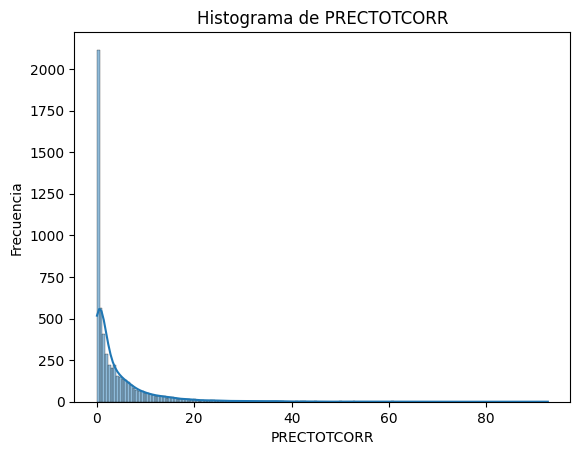

In [27]:
sns.histplot(data=df_total[df_total.PRECTOTCORR > 0], x='PRECTOTCORR', kde=True)
plt.title("Histograma de PRECTOTCORR")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frecuencia")
plt.show()

In [28]:
sorted_prec = df_total[df_total.PRECTOTCORR > 20]['PRECTOTCORR'].sort_values(ascending=False)
print(sorted_prec)

3870    92.66
3869    85.65
3255    84.99
3254    78.71
832     71.93
        ...  
4818    20.21
827     20.19
3246    20.10
7211    20.05
6275    20.03
Name: PRECTOTCORR, Length: 206, dtype: float64


seasonality analysis

In [29]:
df_eda = df_total.copy()

In [30]:
df_eda['Month'] = df_eda['LocalTime'].dt.month
df_eda['Hour'] = df_eda['LocalTime'].dt.hour

Generation by month

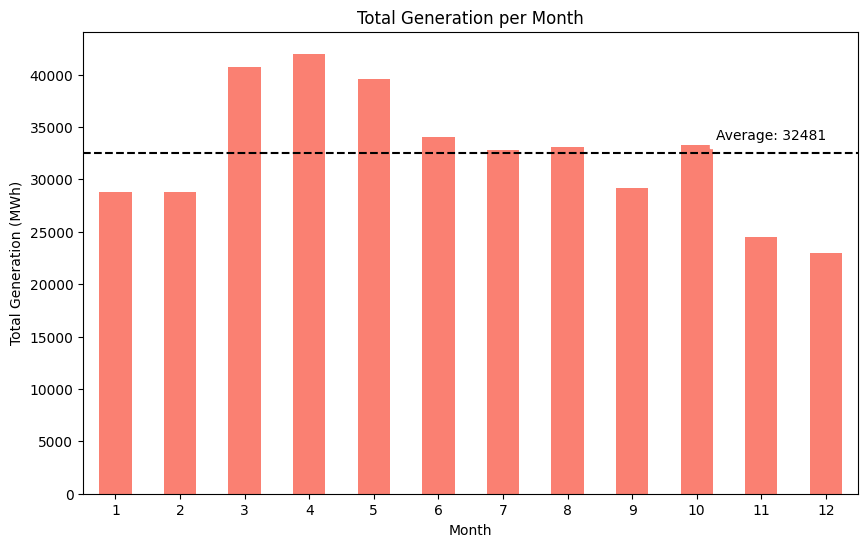

In [31]:
monthly_sum = df_eda.groupby('Month')['Power(MW)_ActualEnergy'].sum()
plt.figure(figsize=(10,6))
monthly_sum.plot(kind='bar', color='salmon')
avg = monthly_sum.mean()
plt.axhline(avg, color='black', linestyle='--')
plt.text(len(monthly_sum)-1, avg + 1000, f"Average: {round(avg):.0f}", va='bottom', ha='right', backgroundcolor='white')
plt.title('Total Generation per Month')
plt.xlabel('Month')
plt.ylabel('Total Generation (MWh)')
plt.xticks(rotation=0)
plt.show()


Months 3, 4 and 5 are the months that generated the most energy, surpassing the rest of the months by far, which may imply that these are the months where this type of plants have the most ideal conditions for energy generation.

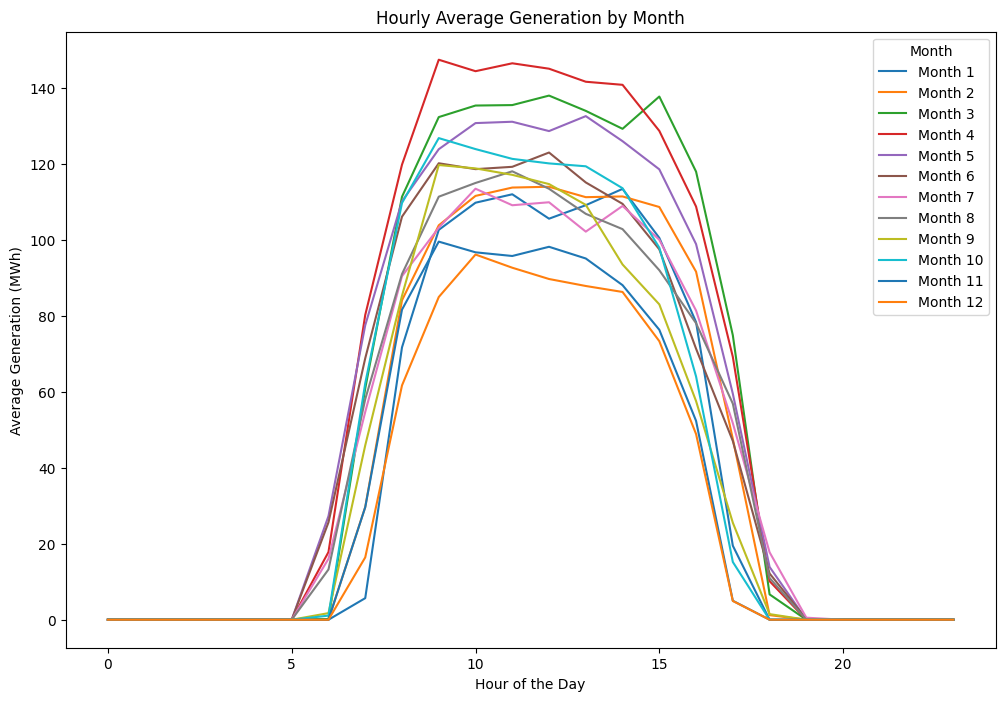

/tmp/ipykernel_1845/153013918.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Power(MW)_ActualEnergy', data=df_eda, palette='Set3')


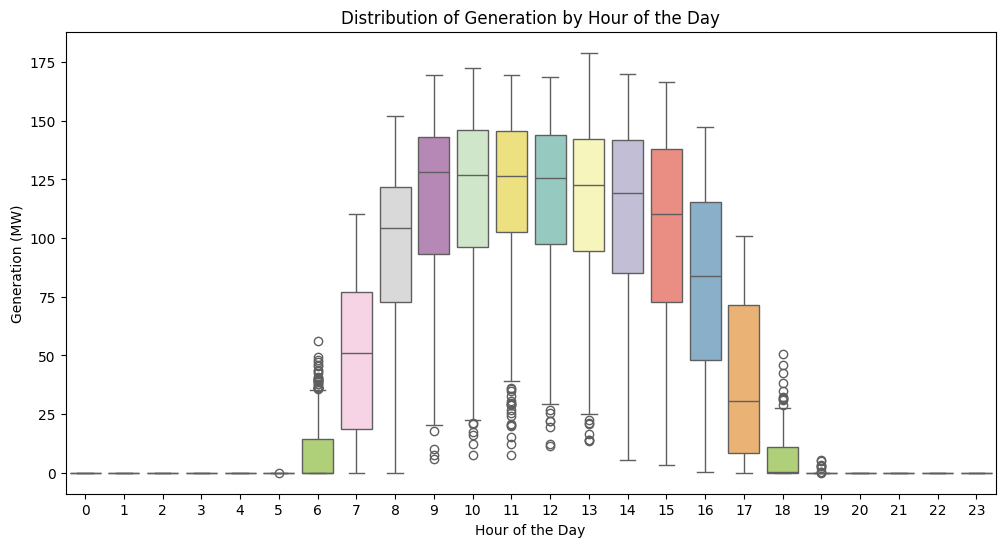

/tmp/ipykernel_1845/153013918.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Power(MW)_ActualEnergy', data=df_month4, palette='Set3')


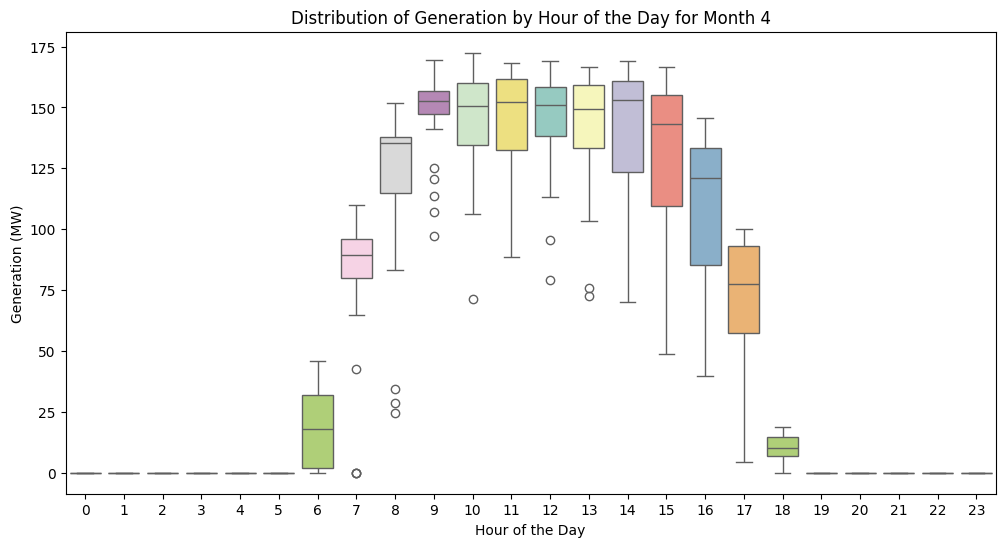

In [32]:
pivot = df_eda.pivot_table(values='Power(MW)_ActualEnergy', index='Hour', columns='Month', aggfunc='mean')


plt.figure(figsize=(12, 8))
for month in sorted(df_eda['Month'].unique()):
    monthly_data = df_eda[df_eda['Month'] == month].groupby('Hour')['Power(MW)_ActualEnergy'].mean()
    plt.plot(monthly_data.index, monthly_data, label=f'Month {month}')
plt.title('Hourly Average Generation by Month')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Generation (MWh)')
plt.legend(title='Month')
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(x='Hour', y='Power(MW)_ActualEnergy', data=df_eda, palette='Set3')
plt.title('Distribution of Generation by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Generation (MW)')
plt.show()


# Filter the DataFrame for month 4
df_month4 = df_eda[df_eda['Month'] == 4]

plt.figure(figsize=(12,6))
sns.boxplot(x='Hour', y='Power(MW)_ActualEnergy', data=df_month4, palette='Set3')
plt.title('Distribution of Generation by Hour of the Day for Month 4')
plt.xlabel('Hour of the Day')
plt.ylabel('Generation (MW)')
plt.show()

* All months have the same hourly generation profile, only varying in magnitude, which makes perfect sense due to the daylight hours of the day.

* Looking at the hourly profile in the boxplot you can see the large variation of hourly power generation throughout the year, which is related to the monthly generation difference.

* The last boxplot is the same distribution but only for month 4, where it can be seen that even for one month, the variability of hourly generation is very large, which shows the importance of having robust models when forecasting.

#### Simulated forecasting evaluation

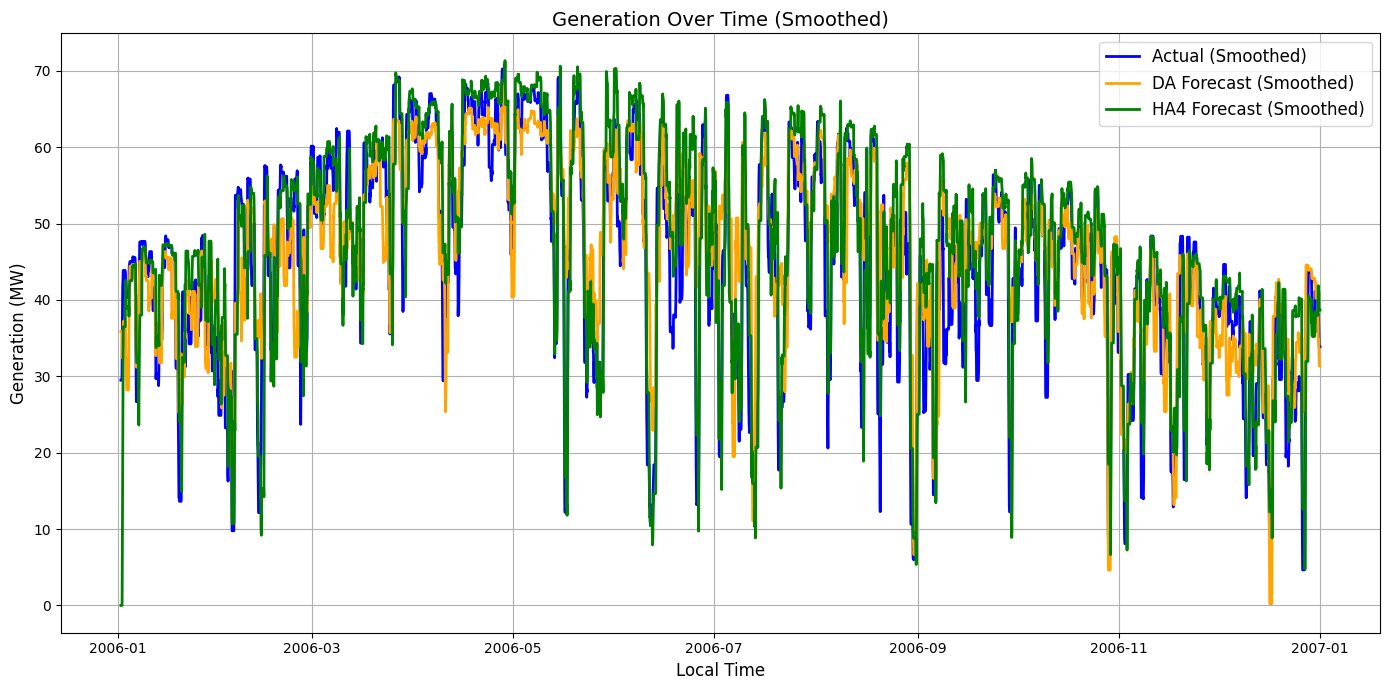

In [33]:
df_fig = df_eda.copy()

df_fig['LocalTime'] = pd.to_datetime(df_fig['LocalTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df_fig.sort_values('LocalTime', inplace=True)

df_fig['Actual_Smoothed'] = df_fig['Power(MW)_ActualEnergy'].rolling(window=24).mean()
df_fig['DA_Smoothed']     = df_fig['Power(MW)_DA'].rolling(window=24).mean()
df_fig['HA4_Smoothed']    = df_fig['Power(MW)_HA4'].rolling(window=24).mean()

plt.figure(figsize=(14, 7))
plt.plot(df_fig['LocalTime'], df_fig['Actual_Smoothed'], label='Actual (Smoothed)', color='blue', linewidth=2)
plt.plot(df_fig['LocalTime'], df_fig['DA_Smoothed'], label='DA Forecast (Smoothed)', color='orange', linewidth=2)
plt.plot(df_fig['LocalTime'], df_fig['HA4_Smoothed'], label='HA4 Forecast (Smoothed)', color='green', linewidth=2)

plt.xlabel('Local Time', fontsize=12)
plt.ylabel('Generation (MW)', fontsize=12)
plt.title('Generation Over Time (Smoothed)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
y_true = df_eda['Power(MW)_ActualEnergy']
y_pred_da = df_eda['Power(MW)_DA']
y_pred_ha4 = df_eda['Power(MW)_HA4']

# Calcular RMSE para DA
rmse_da = np.sqrt(mean_squared_error(y_true, y_pred_da))

# Calcular RMSE para HA4
rmse_ha4 = np.sqrt(mean_squared_error(y_true, y_pred_ha4))

print("RMSE DA Forecast:", rmse_da)
print("RMSE HA4 Forecast:", rmse_ha4)

RMSE DA Forecast: 23.648429636226933
RMSE HA4 Forecast: 23.41356369172875


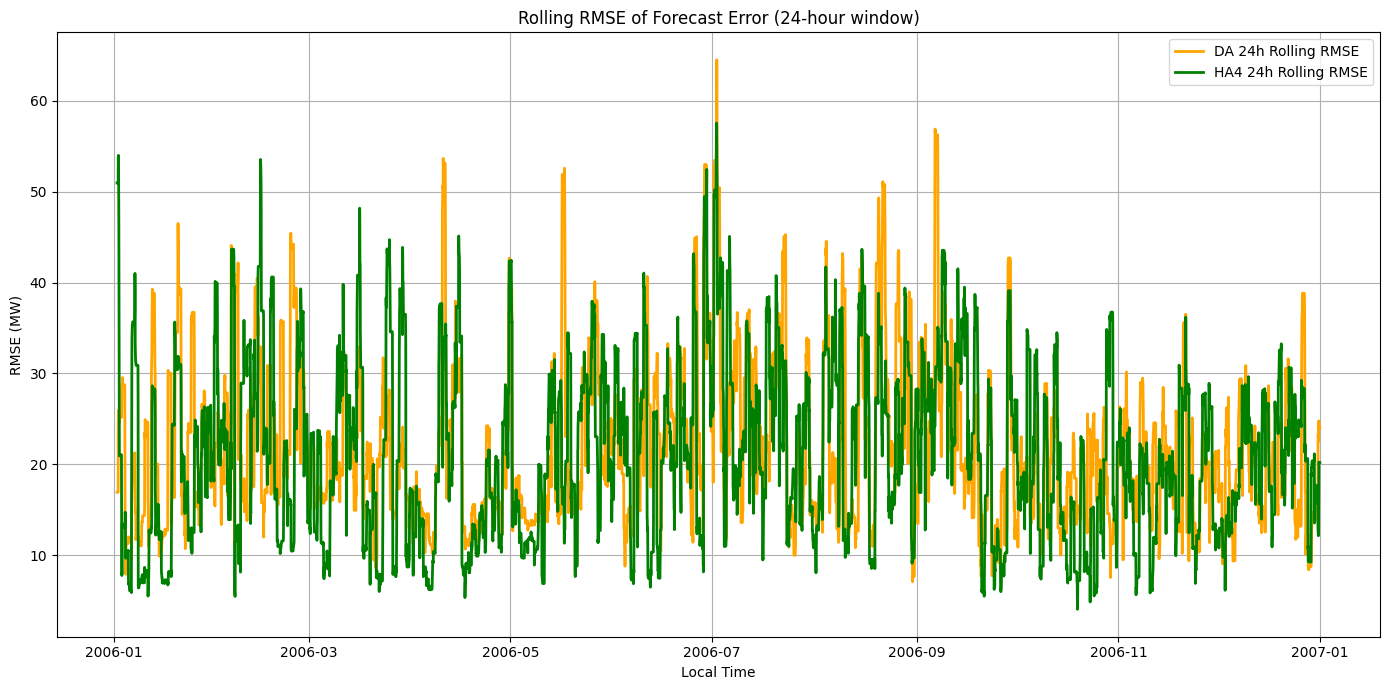

In [35]:

df_err = df_eda.copy()
df_err.sort_values('LocalTime', inplace=True)

# 3. Define error columns for DA and HA4
df_err['Error_DA'] = df_err['Power(MW)_ActualEnergy'] - df_err['Power(MW)_DA']
df_err['Error_HA4'] = df_err['Power(MW)_ActualEnergy'] - df_err['Power(MW)_HA4']

# 4. Compute rolling RMSE (e.g., 24-hour window). Adjust the window to suit your data.
window_size = 24  # 24 hours if data is hourly
df_err['DA_RMSE_24h'] = (df_err['Error_DA'].rolling(window_size).apply(lambda x: np.sqrt(np.mean(x**2))))
df_err['HA4_RMSE_24h'] = (df_err['Error_HA4'].rolling(window_size).apply(lambda x: np.sqrt(np.mean(x**2))))

# 5. Plot rolling RMSE
plt.figure(figsize=(14, 7))
plt.plot(df_err['LocalTime'], df_err['DA_RMSE_24h'], label='DA 24h Rolling RMSE', color='orange', linewidth=2)
plt.plot(df_err['LocalTime'], df_err['HA4_RMSE_24h'], label='HA4 24h Rolling RMSE', color='green', linewidth=2)
plt.xlabel('Local Time')
plt.ylabel('RMSE (MW)')
plt.title('Rolling RMSE of Forecast Error (24-hour window)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


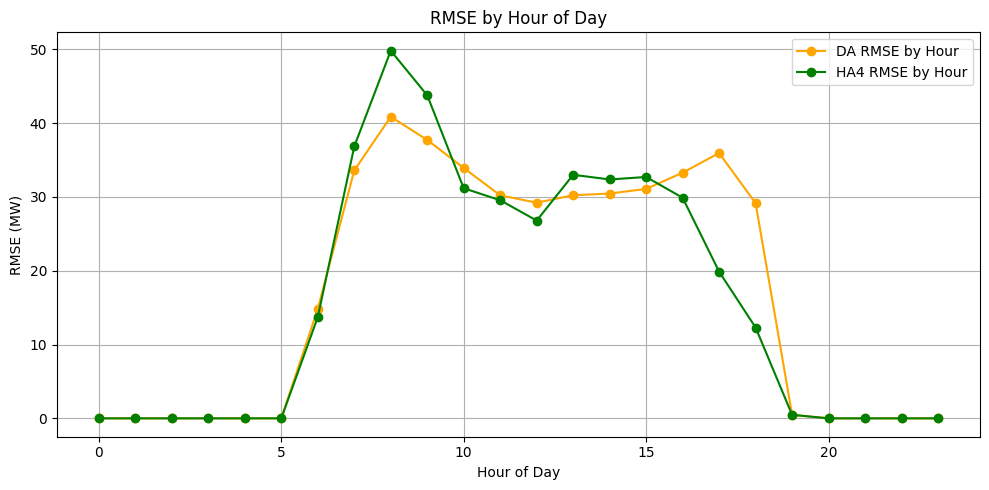

In [36]:

df_hour = df_eda.copy()

# Extract the hour
df_hour['Hour'] = df_hour['LocalTime'].dt.hour

# Define error columns
df_hour['Error_DA'] = df_hour['Power(MW)_ActualEnergy'] - df_hour['Power(MW)_DA']
df_hour['Error_HA4'] = df_hour['Power(MW)_ActualEnergy'] - df_hour['Power(MW)_HA4']

# Compute RMSE (or MAE) grouped by hour
grouped = df_hour.groupby('Hour')
rmse_da_by_hour = grouped['Error_DA'].apply(lambda x: np.sqrt(np.mean(x**2)))
rmse_ha4_by_hour = grouped['Error_HA4'].apply(lambda x: np.sqrt(np.mean(x**2)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(rmse_da_by_hour.index, rmse_da_by_hour.values, label='DA RMSE by Hour', marker='o', color='orange')
plt.plot(rmse_ha4_by_hour.index, rmse_ha4_by_hour.values, label='HA4 RMSE by Hour', marker='o', color='green')
plt.xlabel('Hour of Day')
plt.ylabel('RMSE (MW)')
plt.title('RMSE by Hour of Day')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Due to the data comes from simulated generation, the forecasting data contains a very low error, overcoming these values will be a challenge, but achieving it could mean a good model.

As can be seen the RMSE increases in the morning and afternoon hours, and peaks on different days, these errors can lead to miscalculations of system load complicating grid management by making it difficult to maintain adequate reserves or schedule balancing services

## EDA with the new data

correlation matrix

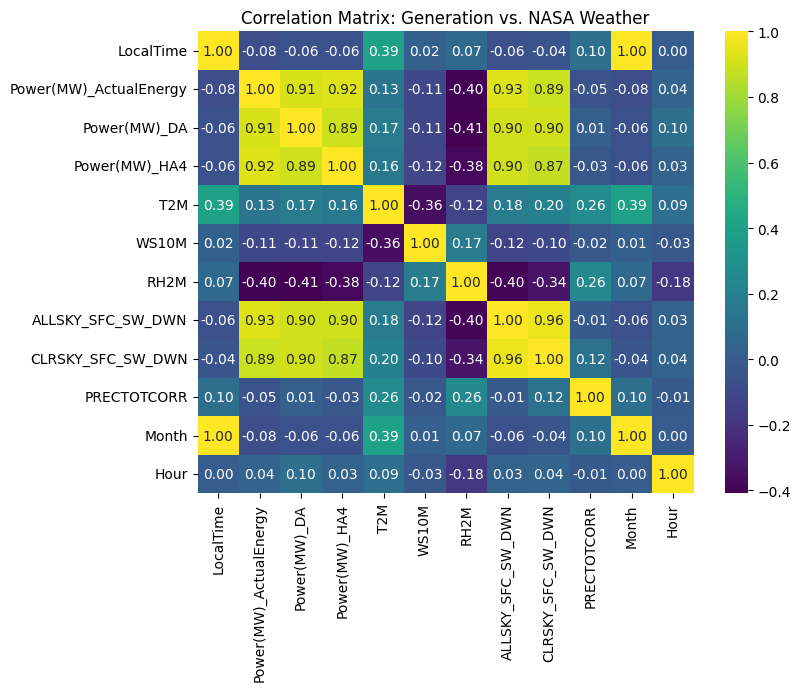

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_of_interest = df_eda.columns

corr_matrix = df_eda[cols_of_interest].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix: Generation vs. NASA Weather')
plt.show()

| Aspect                        | Correlation Summary                                             | Explanation                                                                                                                  |
|-------------------------------|-----------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------|
| Irradiance as Key Driver      | ALLSKY_SFC_SW_DWN (r ≈ 0.93) and CLRSKY_SFC_SW_DWN (r ≈ 0.89)   | Solar irradiance is strongly linked with PV output, confirming that available solar radiation is the primary factor in generation. |
| Humidity Impact               | RH2M shows a moderate negative correlation (r ≈ -0.40)            | Higher relative humidity, often associated with cloudiness, tends to reduce solar generation.                                |
| Temperature Influence         | T2M has a weak positive correlation (r ≈ 0.13)                    | Air temperature appears to have a minor direct effect on generation compared to irradiance and humidity.                     |
| Precipitation Role            | PRECTOTCORR is nearly uncorrelated (r near 0)                     | Precipitation does not exhibit a significant direct relationship with PV generation in this dataset.                        |
| Other Variables               | WS10M, Month, and Hour show low or negligible correlations        | Wind speed and temporal factors (month, hour) have limited direct impact, although they may influence generation indirectly.  |


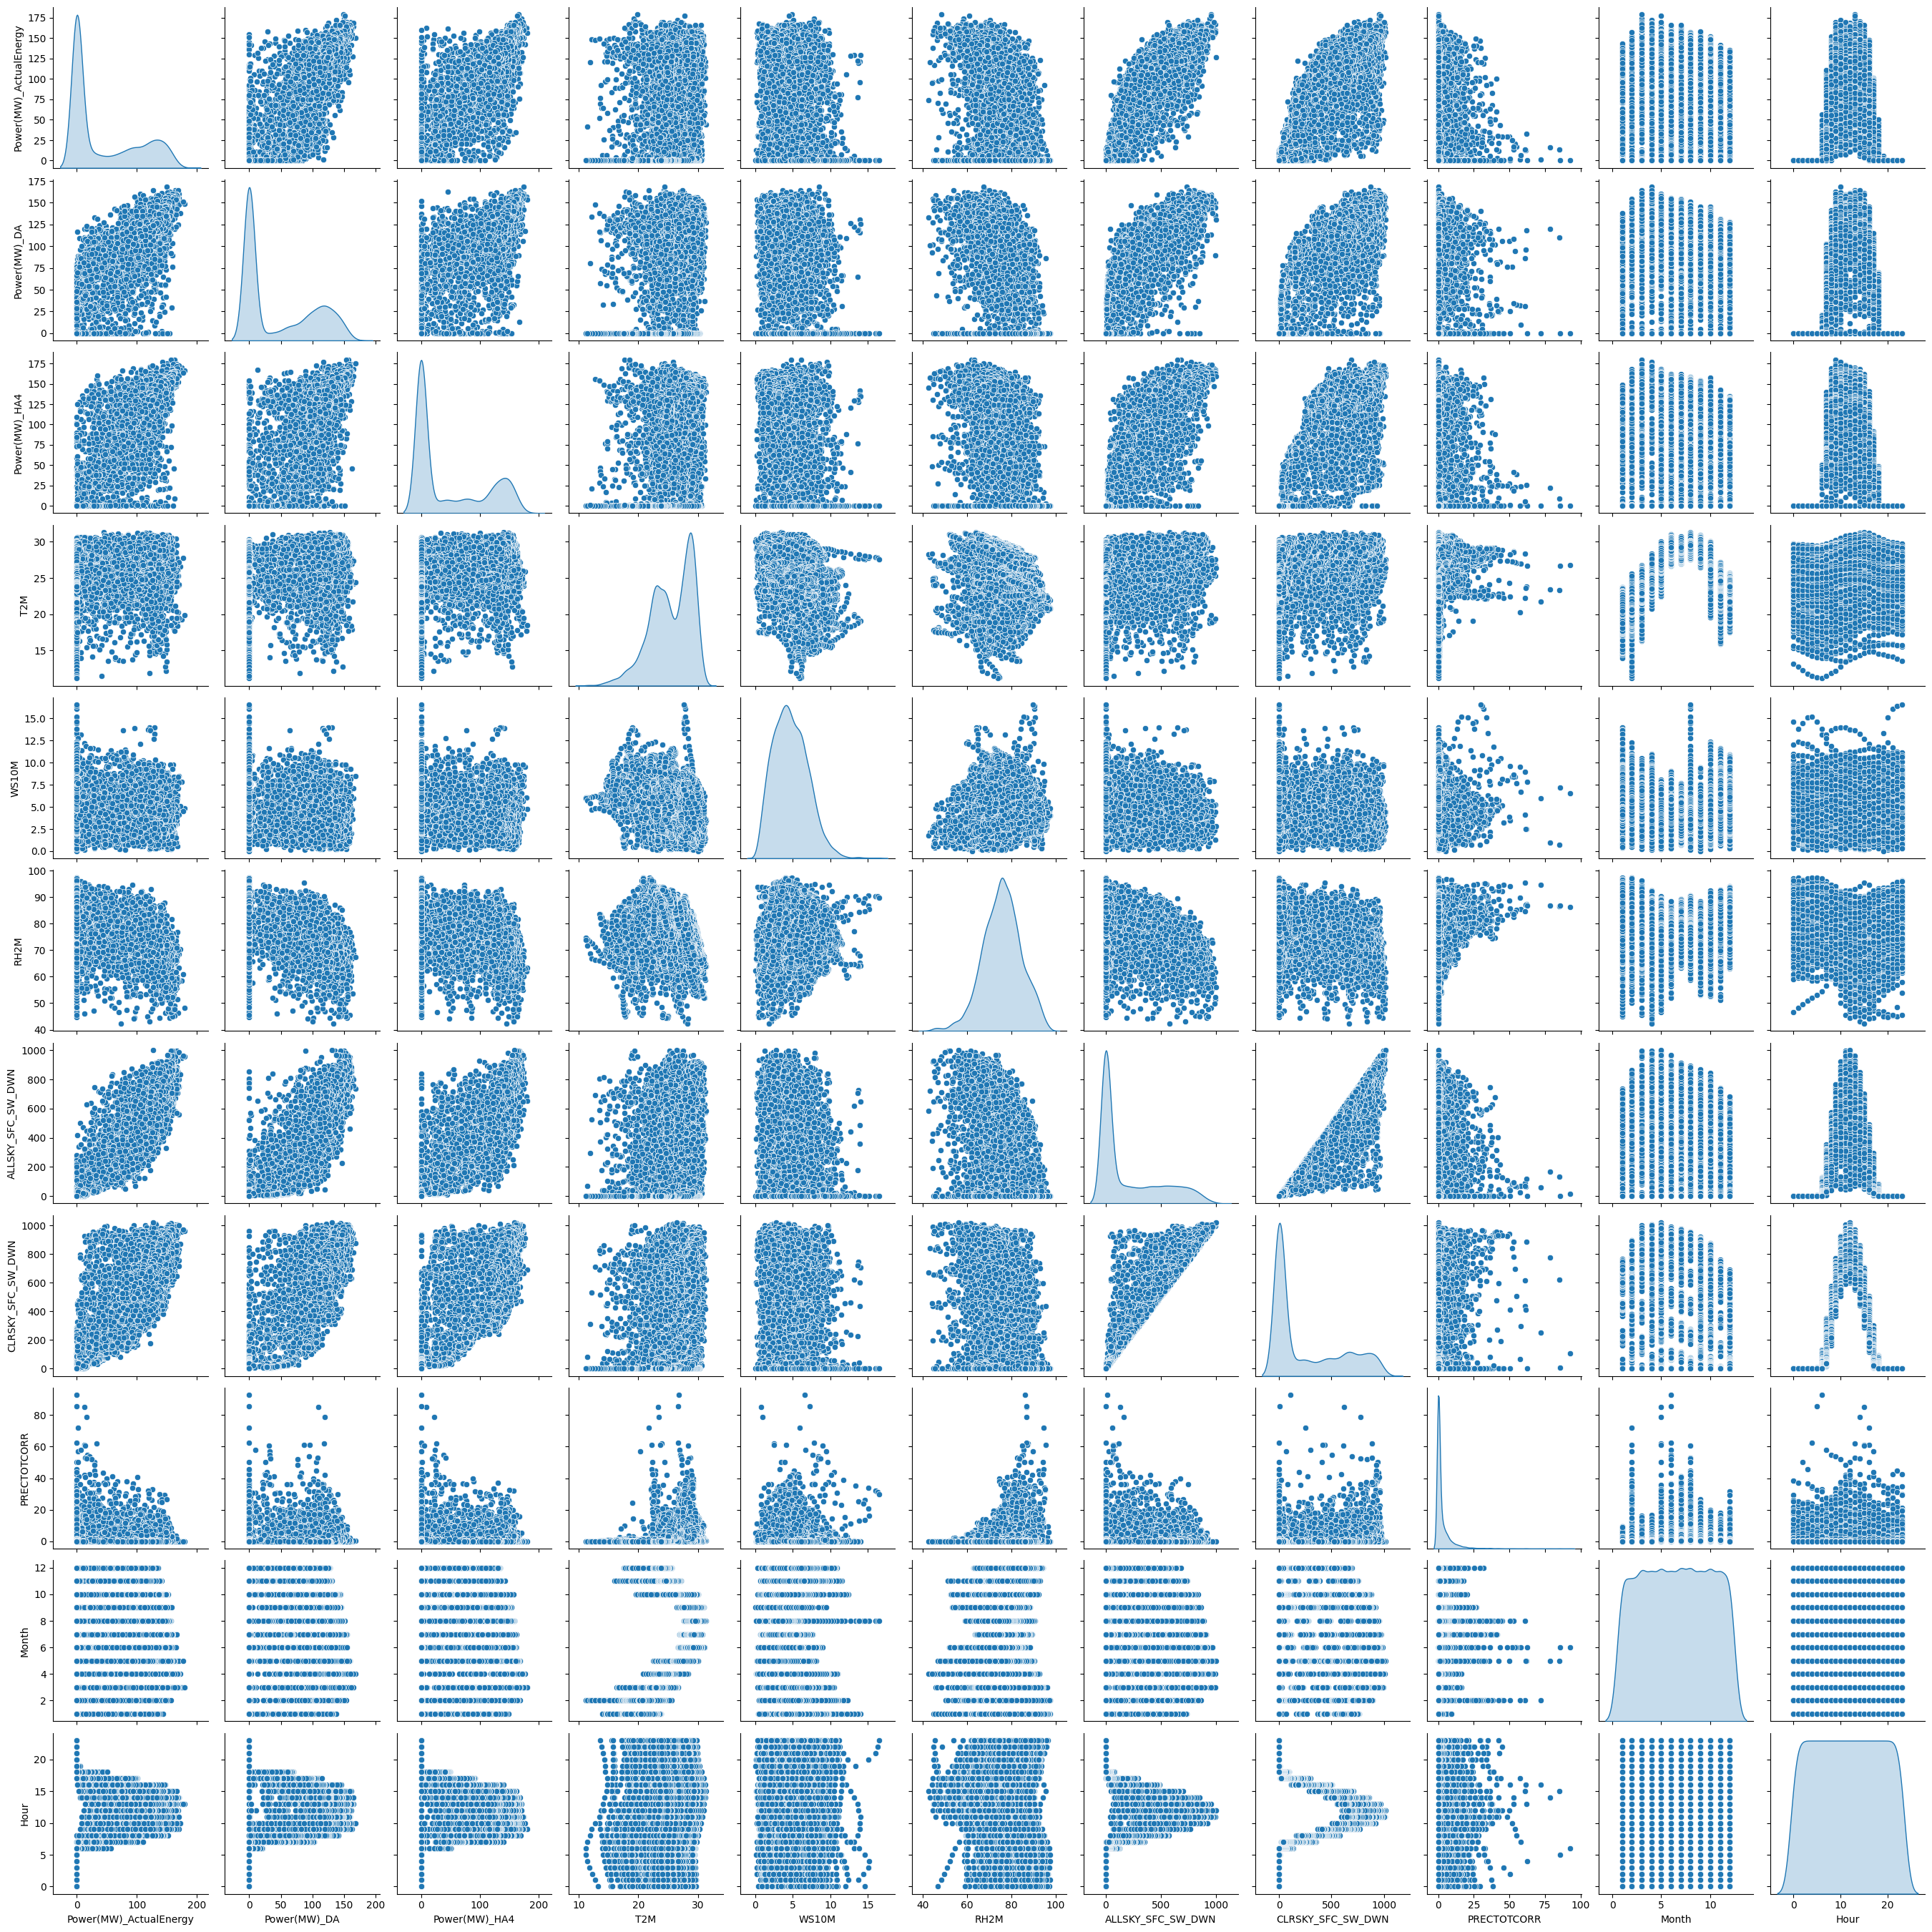

In [38]:
sns.pairplot(df_eda[cols_of_interest], diag_kind='kde')
plt.show()

pairplot for only the data that contain energy (avoid the no sunlight)

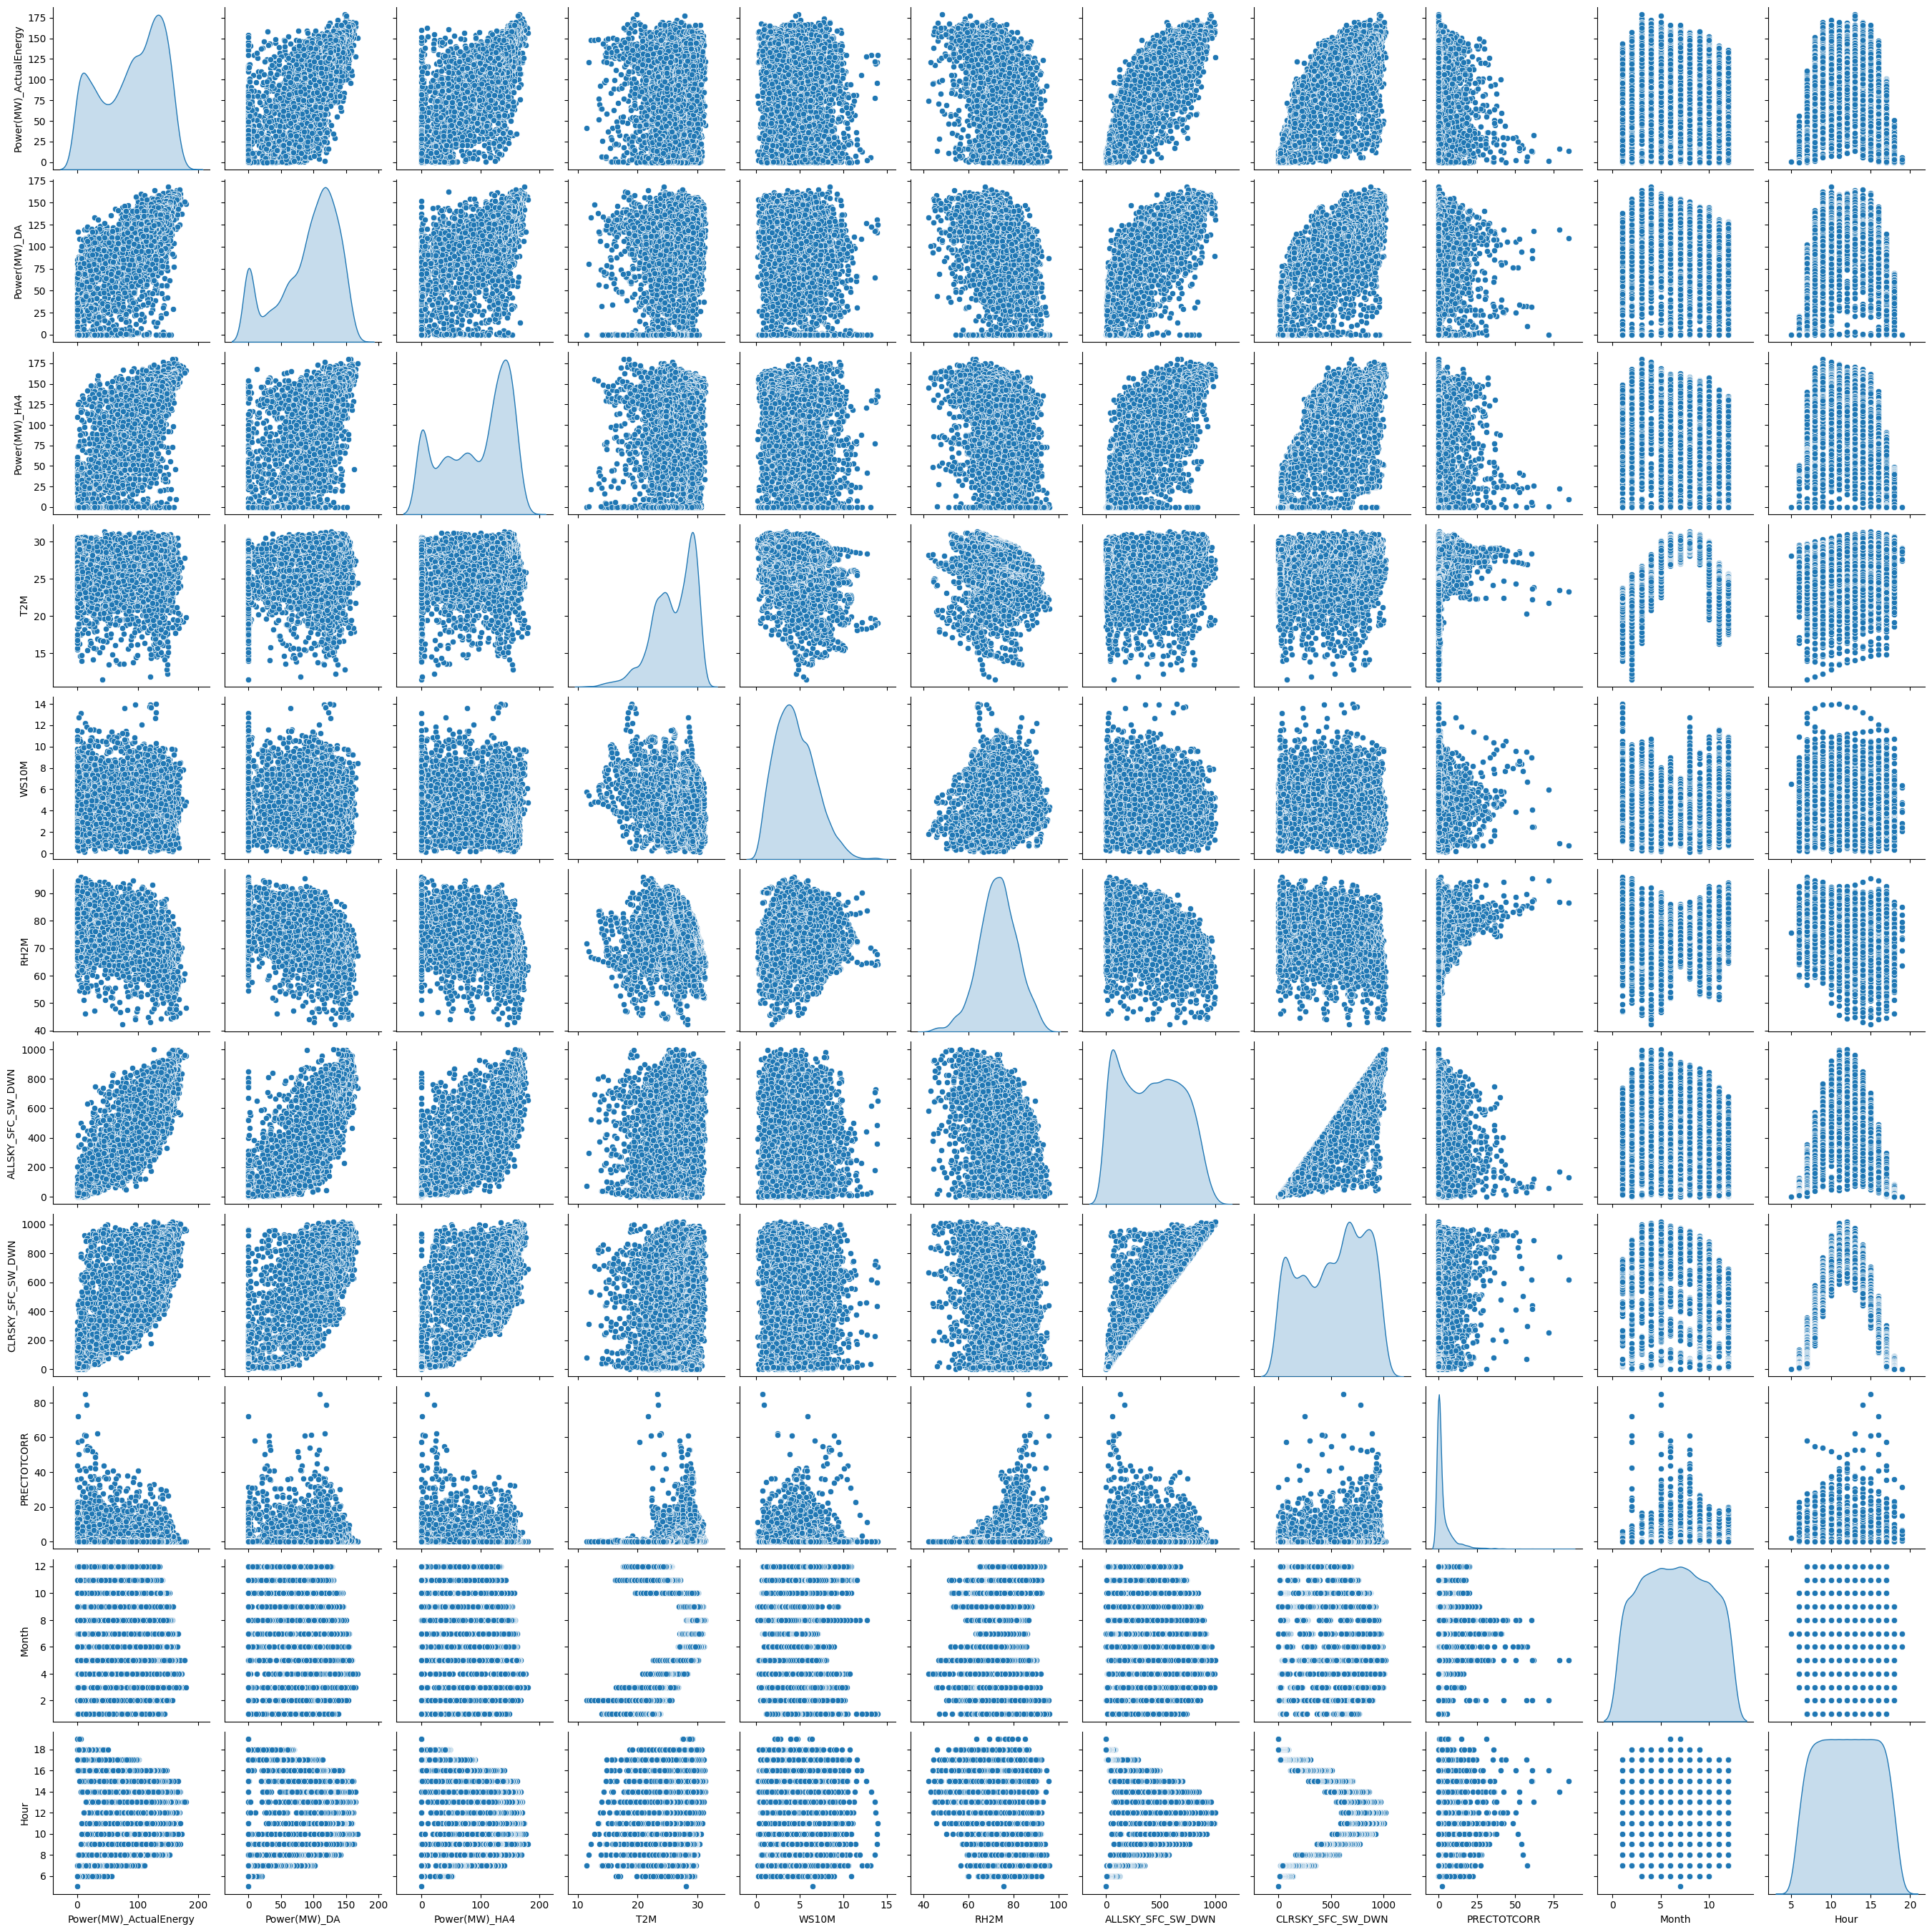

In [39]:
sns.pairplot(df_eda[df_eda['Power(MW)_ActualEnergy'] > 0], diag_kind='kde')
plt.show()



In [44]:
df_eda

,LocalTime,Power(MW)_ActualEnergy,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,Month,Hour
0,2006-01-01 00:00:00,0.0,0.0,0.0,22.16,4.74,95.38,0.0,0.0,0.00,1,0
1,2006-01-01 01:00:00,0.0,0.0,0.0,22.18,4.78,95.06,0.0,0.0,0.00,1,1
2,2006-01-01 02:00:00,0.0,0.0,0.0,22.22,4.80,94.55,0.0,0.0,0.00,1,2
3,2006-01-01 03:00:00,0.0,0.0,0.0,22.26,4.64,94.14,0.0,0.0,0.00,1,3
4,2006-01-01 04:00:00,0.0,0.0,0.0,22.25,4.31,94.10,0.0,0.0,0.02,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2006-12-31 19:00:00,0.0,0.0,0.0,24.01,6.25,85.69,0.0,0.0,0.09,12,19
8756,2006-12-31 20:00:00,0.0,0.0,0.0,23.93,5.75,86.45,0.0,0.0,0.03,12,20
8757,2006-12-31 21:00:00,0.0,0.0,0.0,23.90,5.60,86.62,0.0,0.0,0.00,12,21
8758,2006-12-31 22:00:00,0.0,0.0,0.0,23.89,5.79,86.45,0.0,0.0,0.00,12,22


## CONCLUSIONS

* The complete dataset in terms of amount of data, has been used for several electricity and solar energy studies and together with the data extracted from NASA, allows to have a wide variety of factors that, as seen in the correlation analysis, directly affect solar generation.

* The energy values vary greatly throughout the year and even within a single month, showing the difficulty of accurate forecasting.

* Due to the large influence of weather related data, a predictive model using this data will also depend on how accurate the data estimates of these variables are. While some variables are easy to estimate, others follow complex patterns that do not have accurate estimates over time, this error will add to the intrinsic error of the future model.

* The biggest concern is that this data does not come from a real plant, but from a simulation, so it does not have the 100% real behaviour of what it would actually look like in a plant, which is affected by many more factors.